=== Handle imports and paths ===

In [2]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/')
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/functions/')
from postprocessing import PostProcessor
from config import model_comparison_config as cfg
%load_ext autoreload
%autoreload 2

p = PostProcessor(first=cfg.first)

Create a df with subject LBAGs per-region to match CNN df style

In [ ]:
# Load GNN LBAGs per vertex and subject
gnn_lbags = np.concatenate([np.load(cfg.adni_cn_lbags), 
                            np.load(cfg.adni_mci_lbags),
                            np.load(cfg.adni_ad_lbags)
                            ], axis=0)

# Get subject IDs
cn_ids = np.load(cfg.adni_cn_subjs)
mci_ids = np.load(cfg.adni_mci_subjs)
ad_ids = np.load(cfg.adni_ad_subjs)

# Match GNN subject labels to IDs
gnn_ids = np.concatenate([cn_ids, mci_ids, ad_ids], axis=0)

# Get cohort labels for these subjects
gnn_cohort = np.concatenate([
    np.repeat('CN',  len(cn_ids)),
    np.repeat('MCI', len(mci_ids)),
    np.repeat('AD',  len(ad_ids))
])

# Create a df for the GNN data
rows = []

# Iterate over subjects
for subj_arr, subj_id, subj_cohort in zip(gnn_lbags, gnn_ids, gnn_cohort):

    # Get regional lbags
    region_lbag_dict = p.get_locations(
        subj_arr,
        per='region',
        medial_present=False,
        return_type='mean'
    )

    # Create the row to add to the df
    row = {
        'subject_id': subj_id,
        'cohort': subj_cohort
    }

    # Get lbag per region and subject
    for (region, hemi), val in region_lbag_dict.items():
        col_name = f'ctx_{hemi}_{region}' # to match cnn df
        row[col_name] = val

    rows.append(row)

gnn_df = pd.DataFrame(rows)
gnn_df.to_csv(cfg.gnn_path)

Compare how local patterns of aging vary across cohorts, for the GNN vs. CNN

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load in CNN and GNN data
cnn_df = pd.read_csv(cfg.cnn_path)
gnn_df = pd.read_csv(cfg.gnn_path)

# Ensure ID types match
gnn_df['subject_id'] = gnn_df['subject_id'].astype(str)
cnn_df['ID'] = cnn_df['ID'].astype(str)

# Find overlap
common_ids = np.intersect1d(
    gnn_df['subject_id'].values,
    cnn_df['ID'].values
)

# Filter both dfs
gnn_shared = gnn_df[gnn_df['subject_id'].isin(common_ids)].copy()
cnn_shared = cnn_df[cnn_df['ID'].isin(common_ids)].copy()

# Match ordering
gnn_shared = gnn_shared.set_index('subject_id').loc[common_ids]
cnn_shared = cnn_shared.set_index('ID').loc[common_ids]

# Transfer cohort from GNN to CNN
cnn_shared['cohort'] = gnn_shared['cohort'].values

# Add model labels
gnn_shared['model'] = 'GNN'
cnn_shared['model'] = 'LBA-SotA'

# Function for mapping region to lobe
def add_lobe_averages(df):

    norm_cols = {
        c: c.replace('-', '_').lower()
        for c in df.columns
    }

    for lobe, regions in cfg.region_to_lobe_dict.items():

        cols = []

        for region in regions:
            region_norm = region.replace('-', '_').lower()

            cols.extend([
                orig_col for orig_col, norm_col in norm_cols.items()
                if norm_col.endswith(f'_{region_norm}')
            ])

        if len(cols) == 0:
            continue

        df[f'lobe_{lobe.lower()}'] = df[cols].mean(axis=1)

    return df

# Add lobe averages
gnn_shared = add_lobe_averages(gnn_shared)
cnn_shared = add_lobe_averages(cnn_shared)

# Merge
df = pd.concat([gnn_shared, cnn_shared], axis=0)

# Clean cohort labels
df['cohort'] = (
    df['cohort']
    .astype(str)
    .str.strip()
    .str.upper()
    .str.split()
    .str[-1]
)

# Keep only CN and AD
df = df[df['cohort'].isin(['CN', 'AD'])].copy()

# Get lobe columns
lobe_cols = [c for c in df.columns if c.startswith('lobe_')]

# Long format
plot_df = df.reset_index()[['cohort', 'model'] + lobe_cols]

plot_df = plot_df.melt(
    id_vars=['cohort', 'model'],
    value_vars=lobe_cols,
    var_name='lobe',
    value_name='value'
)
plot_df['value_norm'] = (
    plot_df.groupby('model')['value']
      .transform(lambda x: x)#(x - x.mean()) / x.std())
)
plot_df = plot_df[plot_df['lobe'].str.contains('temporal') | plot_df['lobe'].str.contains('parietal') | plot_df['lobe'].str.contains('frontal') | plot_df['lobe'].str.contains('occipital') | plot_df['lobe'].str.contains('insula')].copy()
plot_df

,cohort,model,lobe,value,value_norm
0,CN,GNN,lobe_frontal,-9.360429,-9.360429
1,CN,GNN,lobe_frontal,-0.703128,-0.703128
2,CN,GNN,lobe_frontal,-0.186476,-0.186476
3,CN,GNN,lobe_frontal,-0.691131,-0.691131
4,CN,GNN,lobe_frontal,-0.938619,-0.938619
...,...,...,...,...,...
17083,CN,LBA-SotA,lobe_insula,-0.388433,-0.388433
17084,CN,LBA-SotA,lobe_insula,-3.603715,-3.603715
17085,CN,LBA-SotA,lobe_insula,-4.138532,-4.138532
17086,CN,LBA-SotA,lobe_insula,-8.392825,-8.392825


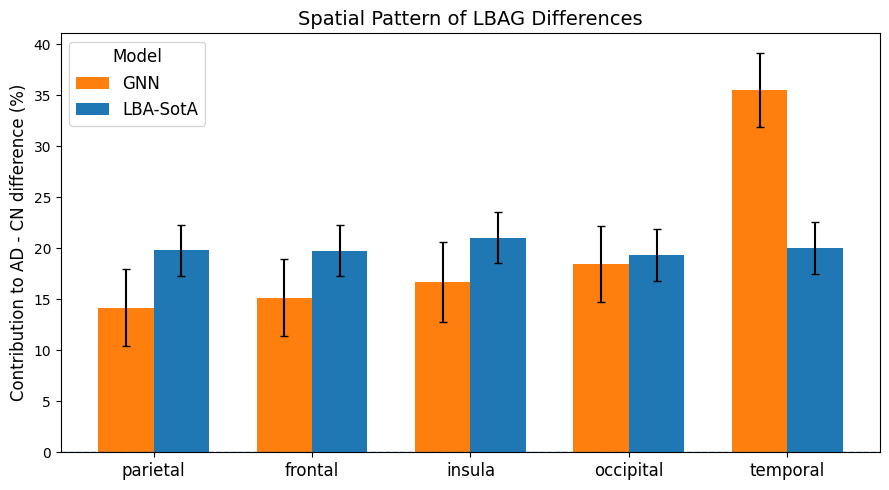

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = plot_df.copy()
plot_df['lobe'] = plot_df['lobe'].str.replace('lobe_', '', regex=False)

summary_df = (
    plot_df
    .groupby(['lobe', 'cohort', 'model'])['value_norm']
    .agg(mean='mean', sem='sem')
    .reset_index()
)

mean_df = summary_df.pivot(index=['lobe', 'model'], columns='cohort', values='mean').reset_index()
sem_df  = summary_df.pivot(index=['lobe', 'model'], columns='cohort', values='sem').reset_index()

delta_df = mean_df.merge(sem_df, on=['lobe', 'model'], suffixes=('', '_sem'))
delta_df['delta'] = delta_df['AD'] - delta_df['CN']
delta_df['delta_sem'] = np.sqrt(delta_df['AD_sem']**2 + delta_df['CN_sem']**2)

# delta_df['delta_abs'] = delta_df['delta'].abs()

# scale = delta_df.groupby('model')['delta_abs'].transform('sum')

# delta_df['delta_pct'] = 100 * delta_df['delta_abs'] / scale
# delta_df['delta_pct_sem'] = 100 * delta_df['delta_sem'] / scale

scale = delta_df.groupby('model')['delta'].transform(lambda s: s.abs().sum())

delta_df['delta_pct'] = 100 * delta_df['delta'] / scale
delta_df['delta_pct_sem'] = 100 * delta_df['delta_sem'] / scale

# Order lobes by GNN pattern
lobe_order = (
    delta_df[delta_df['model'] == 'GNN']
    .sort_values('delta_pct')['lobe']
    .tolist()
)

models = ['GNN', 'LBA-SotA']

model_colors = {
    'GNN': '#ff7f0e',
    'LBA-SotA': '#1f77b4'
}

x = np.arange(len(lobe_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(models):
    sub = delta_df[delta_df['model'] == model].set_index('lobe').reindex(lobe_order)
    xpos = x + (i - (len(models) - 1) / 2) * width

    ax.bar(
        xpos,
        sub['delta_pct'],
        width=width,
        label=model,
        color=model_colors[model]
    )
    ax.errorbar(
        xpos,
        sub['delta_pct'],
        yerr=sub['delta_pct_sem'],
        fmt='none',
        capsize=3,
        color='black'
    )

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(lobe_order)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylabel('Contribution to AD - CN difference (%)', size=12)
ax.set_title('Spatial Pattern of LBAG Differences', size=14)
ax.legend(title='Model', loc='upper left', fontsize=12, title_fontsize=12)

plt.tight_layout()
fig.savefig(f'{cfg.vis_path}model_comparison.png', dpi=1200, pil_kwargs={'quality': 95})